## Importing the libraries

In [7]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Looking at the dataset

In [2]:
data = pd.read_csv(r'cleaned_excel.csv')
data.head()

,TransactionID,CustomerID,PurchaseDate,Product,Category,Quantity,UnitPrice,City,Gender,Age
0,1,CUST2620,24-04-2024,Dress,Women'S Wear,2,1442.0,Mumbai,Female,65
1,1,CUST2620,24-04-2024,Handbag,Accessories,2,3978.0,Bangalore,Male,55
2,2,CUST1409,10-09-2025,Jeans,Bottomwear,1,4821.0,Bangalore,Male,36
3,2,CUST1409,10-09-2025,Belt,Accessories,3,4013.0,Bangalore,Female,58
4,2,CUST1409,10-09-2025,Shorts,Bottomwear,3,4861.0,Mumbai,Male,32


## Detecting the outliers

In [22]:
cols = ['Quantity','UnitPrice','Age']

for i in cols:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    print(f"\n{i}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")

    outliers = data[(data[i] < lower_bound) | (data[i] > upper_bound)]
    print(f"Number of outliers: {len(outliers)}")

    median_value = data[i].median()
    data.loc[data[i] < lower_bound, i] = median_value
    data.loc[data[i] > upper_bound, i] = median_value


Quantity
Lower bound: -1.0
Upper bound: 7.0
Number of outliers: 145

UnitPrice
Lower bound: -2025.625
Upper bound: 7287.375
Number of outliers: 103

Age
Lower bound: -4.5
Upper bound: 87.5
Number of outliers: 22


In [23]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((data[col] < lower) | (data[col] > upper)).sum()

    print(f"{col}: {count} outliers remaining")

Quantity: 0 outliers remaining
UnitPrice: 0 outliers remaining
Age: 0 outliers remaining


## Normalizing the data

In [26]:
cols = ['Quantity', 'UnitPrice', 'Age']

for i in cols:
    min_value = data[i].min()
    max_value = data[i].max()

    data[i + '_Norm'] = (data[i] - min_value)/(max_value - min_value)

print(data.head())

   TransactionID CustomerID PurchaseDate  Product      Category  Quantity  \
0              1   CUST2620   24-04-2024    Dress  Women'S Wear         2   
1              1   CUST2620   24-04-2024  Handbag   Accessories         2   
2              2   CUST1409   10-09-2025    Jeans    Bottomwear         1   
3              2   CUST1409   10-09-2025     Belt   Accessories         3   
4              2   CUST1409   10-09-2025   Shorts    Bottomwear         3   

   UnitPrice       City  Gender  Age  Quantity_Norm  UnitPrice_Norm  Age_Norm  
0     1442.0     Mumbai  Female   65           0.25        0.288515  0.726027  
1     3978.0  Bangalore    Male   55           0.25        0.795918  0.589041  
2     4821.0  Bangalore    Male   36           0.00        0.964586  0.328767  
3     4013.0  Bangalore  Female   58           0.50        0.802921  0.630137  
4     4861.0     Mumbai    Male   32           0.50        0.972589  0.273973  


## Product Analysis

In [38]:
print("Unique Products:",data['Product'].nunique())

print("\nCount of each product:")
print(data["Product"].value_counts())

print("\nCustomer getting how many products (only 5):")
print(data.groupby('CustomerID')['Product'].nunique().head())

print("\nCustomer getting what products (only 5):")
print(data.groupby('CustomerID')['Product'].apply(list).head())

Unique Products: 16

Count of each product:
Product
Jacket      1122
Dress       1114
Scarf       1103
Belt        1097
Sneakers    1097
Socks       1095
Handbag     1088
Hoodie      1067
Shirt       1057
Tie         1050
Cap         1042
Jeans       1031
Skirt        555
Shorts       504
Watch        490
T-Shirt      488
Name: count, dtype: int64

Customer getting how many products (only 5):
CustomerID
CUST0001    5
CUST0002    4
CUST0004    5
CUST0005    5
CUST0007    2
Name: Product, dtype: int64

Customer getting what products (only 5):
CustomerID
CUST0001     [Sneakers, Socks, Dress, Dress, Handbag, Shorts]
CUST0002    [Dress, Handbag, Scarf, Socks, Dress, Handbag,...
CUST0004               [Jacket, Scarf, Socks, Dress, Handbag]
CUST0005                    [Jeans, Belt, Jacket, Scarf, Tie]
CUST0007                                        [Skirt, Belt]
Name: Product, dtype: object


## Removing the duplicated list

In [8]:
transactions = data.groupby('TransactionID')['Product'].apply(lambda x: list(set(x))).tolist()
print("Transactions (only 10):")
print(transactions[:10])

Transactions (only 10):
[['Dress', 'Handbag'], ['Jeans', 'Shorts', 'Sneakers', 'Belt'], ['Sneakers', 'T-Shirt', 'Watch', 'Socks'], ['Jeans', 'Cap', 'Belt'], ['Tie', 'Shirt'], ['Jeans', 'Cap', 'Belt'], ['Dress', 'Skirt', 'Handbag'], ['Jacket', 'Scarf'], ['Socks', 'Hoodie', 'Watch', 'Belt'], ['Hoodie', 'Socks']]


## Transaction Encoding

In [48]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
print(basket.head())

    Belt    Cap  Dress  Handbag  Hoodie  Jacket  Jeans  Scarf  Shirt  Shorts  \
0  False  False   True     True   False   False  False  False  False    True   
1  False  False   True     True   False   False  False   True  False   False   
2  False  False   True     True   False    True  False   True  False   False   
3   True  False  False    False   False    True   True   True  False   False   
4   True  False  False    False   False   False  False  False  False   False   

   Skirt  Sneakers  Socks  T-Shirt    Tie  Watch  
0  False      True   True    False  False  False  
1  False     False   True    False  False  False  
2  False     False   True    False  False  False  
3  False     False  False    False   True  False  
4   True     False  False    False  False  False  


## Frequent Pattern Growth

In [55]:
frequent_items = fpgrowth(basket, min_support=0.2, use_colnames=True)
print(frequent_items.sort_values(by='support', ascending=False))

     support                      itemsets
5   0.363974           frozenset({Jacket})
0   0.362325            frozenset({Dress})
1   0.361500         frozenset({Sneakers})
4   0.357791            frozenset({Scarf})
2   0.356554          frozenset({Handbag})
6   0.351195             frozenset({Belt})
9   0.351195           frozenset({Hoodie})
10  0.347898            frozenset({Shirt})
3   0.346249            frozenset({Socks})
7   0.339654              frozenset({Tie})
11  0.338417              frozenset({Cap})
8   0.337593            frozenset({Jeans})
14  0.259275    frozenset({Jacket, Scarf})
13  0.244435  frozenset({Sneakers, Socks})
17  0.243199      frozenset({Cap, Hoodie})
12  0.242786   frozenset({Dress, Handbag})
15  0.241962       frozenset({Shirt, Tie})
16  0.237016      frozenset({Jeans, Belt})


## Association Rules

In [62]:
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)

rules = rules.sort_values(
    by='confidence',
    ascending=False
)

print("\nTop 10 Rules")

print(rules[[
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
]].head(10))


Top 10 Rules
              antecedents            consequents   support  confidence  \
5      frozenset({Scarf})    frozenset({Jacket})  0.259275    0.724654   
10       frozenset({Cap})    frozenset({Hoodie})  0.243199    0.718636   
7        frozenset({Tie})     frozenset({Shirt})  0.241962    0.712379   
4     frozenset({Jacket})     frozenset({Scarf})  0.259275    0.712344   
3      frozenset({Socks})  frozenset({Sneakers})  0.244435    0.705952   
8      frozenset({Jeans})      frozenset({Belt})  0.237016    0.702076   
6      frozenset({Shirt})       frozenset({Tie})  0.241962    0.695498   
11    frozenset({Hoodie})       frozenset({Cap})  0.243199    0.692488   
1    frozenset({Handbag})     frozenset({Dress})  0.242786    0.680925   
2   frozenset({Sneakers})     frozenset({Socks})  0.244435    0.676169   

        lift  
5   1.990953  
10  2.046256  
7   2.047667  
4   1.990953  
3   1.952840  
8   1.999103  
6   2.047667  
11  2.046256  
1   1.879322  
2   1.952840  


In [74]:
top_rules = rules.sort_values(by='lift',ascending=False)

print(top_rules[[
              'antecedents',
              'consequents',
              'support',
              'confidence',
              'lift'
]])

              antecedents            consequents   support  confidence  \
7        frozenset({Tie})     frozenset({Shirt})  0.241962    0.712379   
6      frozenset({Shirt})       frozenset({Tie})  0.241962    0.695498   
11    frozenset({Hoodie})       frozenset({Cap})  0.243199    0.692488   
10       frozenset({Cap})    frozenset({Hoodie})  0.243199    0.718636   
8      frozenset({Jeans})      frozenset({Belt})  0.237016    0.702076   
9       frozenset({Belt})     frozenset({Jeans})  0.237016    0.674883   
4     frozenset({Jacket})     frozenset({Scarf})  0.259275    0.712344   
5      frozenset({Scarf})    frozenset({Jacket})  0.259275    0.724654   
2   frozenset({Sneakers})     frozenset({Socks})  0.244435    0.676169   
3      frozenset({Socks})  frozenset({Sneakers})  0.244435    0.705952   
0      frozenset({Dress})   frozenset({Handbag})  0.242786    0.670080   
1    frozenset({Handbag})     frozenset({Dress})  0.242786    0.680925   

        lift  
7   2.047667  
6   2.0

## Product Pairs

In [75]:
pairs = frequent_items[frequent_items['itemsets'].apply(len) == 2]

pairs = pairs.sort_values(by='support',ascending=False)

print("Most Frequent Product Pairs")
print(pairs)

Most Frequent Product Pairs
     support                      itemsets
14  0.259275    frozenset({Jacket, Scarf})
13  0.244435  frozenset({Sneakers, Socks})
17  0.243199      frozenset({Cap, Hoodie})
12  0.242786   frozenset({Dress, Handbag})
15  0.241962       frozenset({Shirt, Tie})
16  0.237016      frozenset({Jeans, Belt})


## Business Insights

In [76]:
print("Business Insights\n")
for index, row in top_rules.iterrows():
    print(f"If customer buys "
        f"{set(row['antecedents'])}, "
        f"they are likely to buy "
        f"{set(row['consequents'])}"
    )
    print(f"Support : {row['support']:.2f}")
    print(f"Confidence : {row['confidence']:.2f}")
    print(f"Lift : {row['lift']:.2f}")
    print("-" * 60)

Business Insights

If customer buys {'Tie'}, they are likely to buy {'Shirt'}
Support : 0.24
Confidence : 0.71
Lift : 2.05
------------------------------------------------------------
If customer buys {'Shirt'}, they are likely to buy {'Tie'}
Support : 0.24
Confidence : 0.70
Lift : 2.05
------------------------------------------------------------
If customer buys {'Hoodie'}, they are likely to buy {'Cap'}
Support : 0.24
Confidence : 0.69
Lift : 2.05
------------------------------------------------------------
If customer buys {'Cap'}, they are likely to buy {'Hoodie'}
Support : 0.24
Confidence : 0.72
Lift : 2.05
------------------------------------------------------------
If customer buys {'Jeans'}, they are likely to buy {'Belt'}
Support : 0.24
Confidence : 0.70
Lift : 2.00
------------------------------------------------------------
If customer buys {'Belt'}, they are likely to buy {'Jeans'}
Support : 0.24
Confidence : 0.67
Lift : 2.00
------------------------------------------------

## Saving the Rules

In [77]:
rules.to_csv('association_rules.csv',index=False)
print("\nAssociation Rules Saved Successfully")


Association Rules Saved Successfully


## K means

In [89]:
X = data[['Quantity_Norm','UnitPrice_Norm','Age_Norm']]

kmeans = KMeans(n_clusters=3,random_state=0)
data['Clusters'] = kmeans.fit_predict(X)

print(data[['Quantity','UnitPrice','Age','Clusters']].head())
print(data['Clusters'].value_counts())

   Quantity  UnitPrice  Age  Clusters
0         2     1442.0   65         2
1         2     3978.0   55         0
2         1     4821.0   36         0
3         3     4013.0   58         0
4         3     4861.0   32         0
Clusters
1    6000
2    4914
0    4086
Name: count, dtype: int64


In [90]:
cluster_summary = data.groupby('Clusters')[['Quantity','UnitPrice','Age']].mean()
print(cluster_summary)

          Quantity    UnitPrice        Age
Clusters                                  
0         2.036955  3850.441263  41.017376
1         4.501500  2613.255000  41.163833
2         1.998168  1557.522182  41.725885


In [93]:
data.groupby('TransactionID')['Product'].apply(list).tolist()


[['Dress', 'Handbag'],
 ['Jeans', 'Belt', 'Shorts', 'Sneakers'],
 ['Sneakers', 'Socks', 'Watch', 'T-Shirt', 'Sneakers'],
 ['Jeans', 'Belt', 'Cap'],
 ['Shirt', 'Tie'],
 ['Jeans', 'Belt', 'Cap'],
 ['Dress', 'Handbag', 'Skirt'],
 ['Jacket', 'Scarf', 'Scarf', 'Scarf'],
 ['Socks', 'Hoodie', 'Belt', 'Watch'],
 ['Hoodie', 'Socks'],
 ['Hoodie', 'Cap'],
 ['Cap', 'Watch', 'Jeans'],
 ['Tie', 'Jeans', 'Socks', 'Jeans'],
 ['Dress', 'Handbag'],
 ['Sneakers', 'Socks', 'Sneakers'],
 ['Hoodie', 'Cap', 'Handbag'],
 ['Watch', 'Cap', 'Dress'],
 ['Dress', 'Handbag', 'Socks', 'Belt'],
 ['Shirt', 'Tie', 'Shorts'],
 ['Sneakers', 'Handbag', 'Tie'],
 ['Jacket', 'Scarf', 'Belt', 'Skirt'],
 ['Sneakers', 'Socks'],
 ['Sneakers', 'Socks'],
 ['Dress', 'Handbag'],
 ['Shirt', 'Tie', 'Jacket', 'Shirt'],
 ['Shirt', 'Tie'],
 ['T-Shirt', 'Hoodie', 'Watch'],
 ['Jacket', 'Scarf'],
 ['Scarf', 'Dress'],
 ['Socks', 'Belt', 'Hoodie', 'Hoodie'],
 ['Watch', 'Scarf', 'Watch'],
 ['Tie', 'Shorts'],
 ['Cap', 'Scarf'],
 ['Shirt', 'Tie'

In [5]:
outlier_summary = []

for col in ['Quantity', 'UnitPrice', 'Age']:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((data[col] < lower) | (data[col] > upper)).sum()

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier_Count']
)

print(outlier_df)

      Column  Outlier_Count
0   Quantity            145
1  UnitPrice            103
2        Age             22


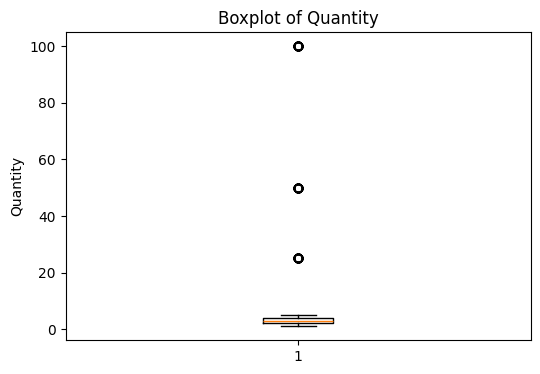

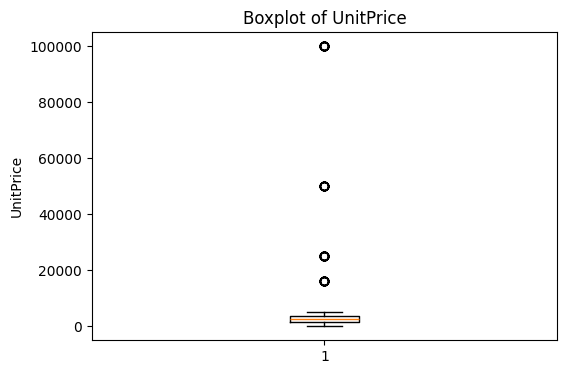

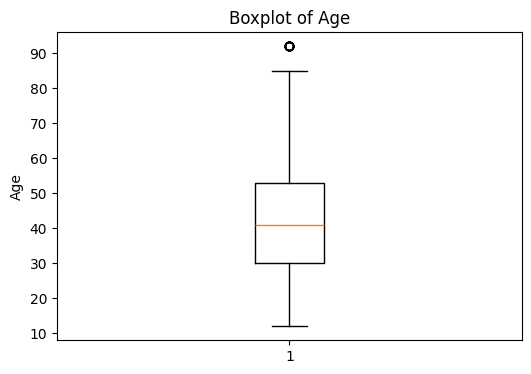

In [6]:
for col in ['Quantity', 'UnitPrice', 'Age']:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data[col].dropna())

    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

    plt.show()